# Classfication Models on Original vs PCA-Reduced Data

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✓ Libraries imported successfully!
Pandas version: 2.0.3
NumPy version: 1.24.3


## 1. LOAD DỮ LIỆU

In [31]:
import json

# Load data
df = pd.read_csv('../data/processed/data_normalized.csv')
print(f"✓ Data loaded: {df.shape}")

# Load metadata
with open('../data/processed/metadata.json', 'r') as f:
    metadata = json.load(f)

target_col = metadata['target_column']
print(f"✓ Target variable: {target_col}")

# Separate features and target
y = df[target_col].values  # JobSatisfaction: 1, 2, 3, 4
X = df.drop(target_col, axis=1).values
feature_names = df.drop(target_col, axis=1).columns.tolist()

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of features: {len(feature_names)}")

# Kiểm tra phân phối các lớp
print(f"\nPhân phối JobSatisfaction:")
unique, counts = np.unique(y, return_counts=True)
for val, count in zip(unique, counts):
    print(f"  Lớp {int(val)}: {count} mẫu ({count / len(y) * 100:.2f}%)")

✓ Data loaded: (1470, 46)
✓ Target variable: JobSatisfaction

Features shape: (1470, 45)
Target shape: (1470,)
Number of features: 45

Phân phối JobSatisfaction:
  Lớp 1: 289 mẫu (19.66%)
  Lớp 2: 280 mẫu (19.05%)
  Lớp 3: 442 mẫu (30.07%)
  Lớp 4: 459 mẫu (31.22%)


## 2. ĐỊNH NGHĨA CÁC TỈ LỆ CHIA DỮ LIỆU

In [32]:
train_test_splits = [
    (0.8, 0.2),  # 8:2
    (0.7, 0.3),  # 7:3
    (0.6, 0.4)  # 6:4
]
print("\nTỉ lệ chia train:test:")
for train_size, test_size in train_test_splits:
    print(f"  {int(train_size * 10)}:{int(test_size * 10)}")


Tỉ lệ chia train:test:
  8:2
  7:3
  6:4


## 3. IMPORT CÁC MÔ HÌNH PHÂN LOẠI

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Nhóm 1: K-NN, Cây quyết định, Naïve Bayes
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Nhóm 2: Hồi quy Softmax-Logistic, MLP
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# Nhóm 3: SVM
from sklearn.svm import SVC

print("✓ All classification models imported!")

✓ All classification models imported!


## 4. HÀM TRAIN VÀ ĐÁNH GIÁ

In [34]:
def train_and_evaluate_classification(X_train, X_test, y_train, y_test,
                                      model_name, data_type, split_ratio, results_dict):
    """
    Train và evaluate classification model
    """
    # Khởi tạo models
    models = {
        # Nhóm 1
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
        'Naive Bayes': GaussianNB(),

        # Nhóm 2
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'),
        'MLP': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),

        # Nhóm 3
        'SVM': SVC(kernel='rbf', random_state=42, probability=True)
    }

    model = models[model_name]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Lưu kết quả
    results_dict['split'].append(split_ratio)
    results_dict['model'].append(model_name)
    results_dict['data_type'].append(data_type)
    results_dict['accuracy'].append(accuracy)
    results_dict['precision'].append(precision)
    results_dict['recall'].append(recall)
    results_dict['f1'].append(f1)

    return model, y_pred

## 5. CHẠY EXPERIMENTS VỚI TẤT CẢ CÁC MÔ HÌNH

In [35]:
# Dictionary lưu kết quả
results_classification = {
    'split': [],
    'model': [],
    'data_type': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

# Chọn 3 models từ 3 nhóm khác nhau
selected_models = ['Naive Bayes', 'Logistic Regression', 'SVM']

print("\n" + "=" * 80)
print("CHẠY EXPERIMENTS (FIXED VERSION - NO DATA LEAKAGE)")
print("=" * 80)
print(f"Models được chọn: {selected_models}")

for train_size, test_size in train_test_splits:
    split_ratio = f"{int(train_size * 10)}:{int(test_size * 10)}"
    print(f"\n{'=' * 80}")
    print(f"Split ratio: {split_ratio}")
    print(f"{'=' * 80}")

    # ===== CHIA DỮ LIỆU =====
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

    # ===== DỮ LIỆU GỐC =====
    print(f"\n--- Dữ liệu GỐC (Original) ---")
    for model_name in selected_models:
        print(f"  Training {model_name}...", end='')
        train_and_evaluate_classification(
            X_train, X_test, y_train, y_test,
            model_name, 'Original', split_ratio, results_classification
        )
        print(" ✓")

    # ===== DỮ LIỆU GIẢM CHIỀU (PCA) - FIXED VERSION =====
    print(f"\n--- Dữ liệu GIẢM CHIỀU (PCA - FIXED) ---")

    # QUAN TRỌNG: Fit PCA chỉ trên TRAIN set
    pca = PCA(n_components=0.95, random_state=42)
    X_train_pca = pca.fit_transform(X_train)  # Fit + transform trên train
    X_test_pca = pca.transform(X_test)  # Chỉ transform trên test

    n_components = X_train_pca.shape[1]
    variance_explained = pca.explained_variance_ratio_.sum()

    print(f"  PCA components: {n_components} (giữ {variance_explained * 100:.2f}% variance)")
    print(f"  Train PCA shape: {X_train_pca.shape}, Test PCA shape: {X_test_pca.shape}")

    for model_name in selected_models:
        print(f"  Training {model_name}...", end='')
        train_and_evaluate_classification(
            X_train_pca, X_test_pca, y_train, y_test,
            model_name, 'PCA_Reduced', split_ratio, results_classification
        )
        print(" ✓")


CHẠY EXPERIMENTS (FIXED VERSION - NO DATA LEAKAGE)
Models được chọn: ['Naive Bayes', 'Logistic Regression', 'SVM']

Split ratio: 8:2
Train set: (1176, 45), Test set: (294, 45)

--- Dữ liệu GỐC (Original) ---
  Training Naive Bayes... ✓
  Training Logistic Regression... ✓
  Training SVM... ✓

--- Dữ liệu GIẢM CHIỀU (PCA - FIXED) ---
  PCA components: 26 (giữ 95.16% variance)
  Train PCA shape: (1176, 26), Test PCA shape: (294, 26)
  Training Naive Bayes... ✓
  Training Logistic Regression... ✓
  Training SVM... ✓

Split ratio: 7:3
Train set: (1029, 45), Test set: (441, 45)

--- Dữ liệu GỐC (Original) ---
  Training Naive Bayes... ✓
  Training Logistic Regression... ✓
  Training SVM... ✓

--- Dữ liệu GIẢM CHIỀU (PCA - FIXED) ---
  PCA components: 26 (giữ 95.27% variance)
  Train PCA shape: (1029, 26), Test PCA shape: (441, 26)
  Training Naive Bayes... ✓
  Training Logistic Regression... ✓
  Training SVM... ✓

Split ratio: 6:4
Train set: (882, 45), Test set: (588, 45)

--- Dữ liệu GỐC (

## 6. HIỂN THỊ KẾT QUẢ


In [36]:
# Tạo DataFrame kết quả
results_df = pd.DataFrame(results_classification)

print("\n" + "=" * 80)
print("KẾT QUẢ PHÂN LOẠI (CLASSIFICATION RESULTS - FIXED)")
print("=" * 80)
print(results_df.to_string(index=False))
print("=" * 80)

# Tính trung bình theo model và data type
print("\n--- Trung bình theo Model và Data Type ---")
avg_results = results_df.groupby(['model', 'data_type'])[['accuracy', 'precision', 'recall', 'f1']].mean()
print(avg_results)


KẾT QUẢ PHÂN LOẠI (CLASSIFICATION RESULTS - FIXED)
split               model   data_type  accuracy  precision   recall       f1
  8:2         Naive Bayes    Original  0.275510   0.274422 0.275510 0.273059
  8:2 Logistic Regression    Original  0.302721   0.295164 0.302721 0.279734
  8:2                 SVM    Original  0.244898   0.151377 0.244898 0.187099
  8:2         Naive Bayes PCA_Reduced  0.258503   0.235581 0.258503 0.237169
  8:2 Logistic Regression PCA_Reduced  0.292517   0.261773 0.292517 0.247230
  8:2                 SVM PCA_Reduced  0.255102   0.159467 0.255102 0.196253
  7:3         Naive Bayes    Original  0.308390   0.304149 0.308390 0.304700
  7:3 Logistic Regression    Original  0.340136   0.314926 0.340136 0.315896
  7:3                 SVM    Original  0.294785   0.179959 0.294785 0.223048
  7:3         Naive Bayes PCA_Reduced  0.281179   0.252994 0.281179 0.259108
  7:3 Logistic Regression PCA_Reduced  0.303855   0.282083 0.303855 0.268218
  7:3                 SV

## 7. TRỰC QUAN HÓA KẾT QUẢ


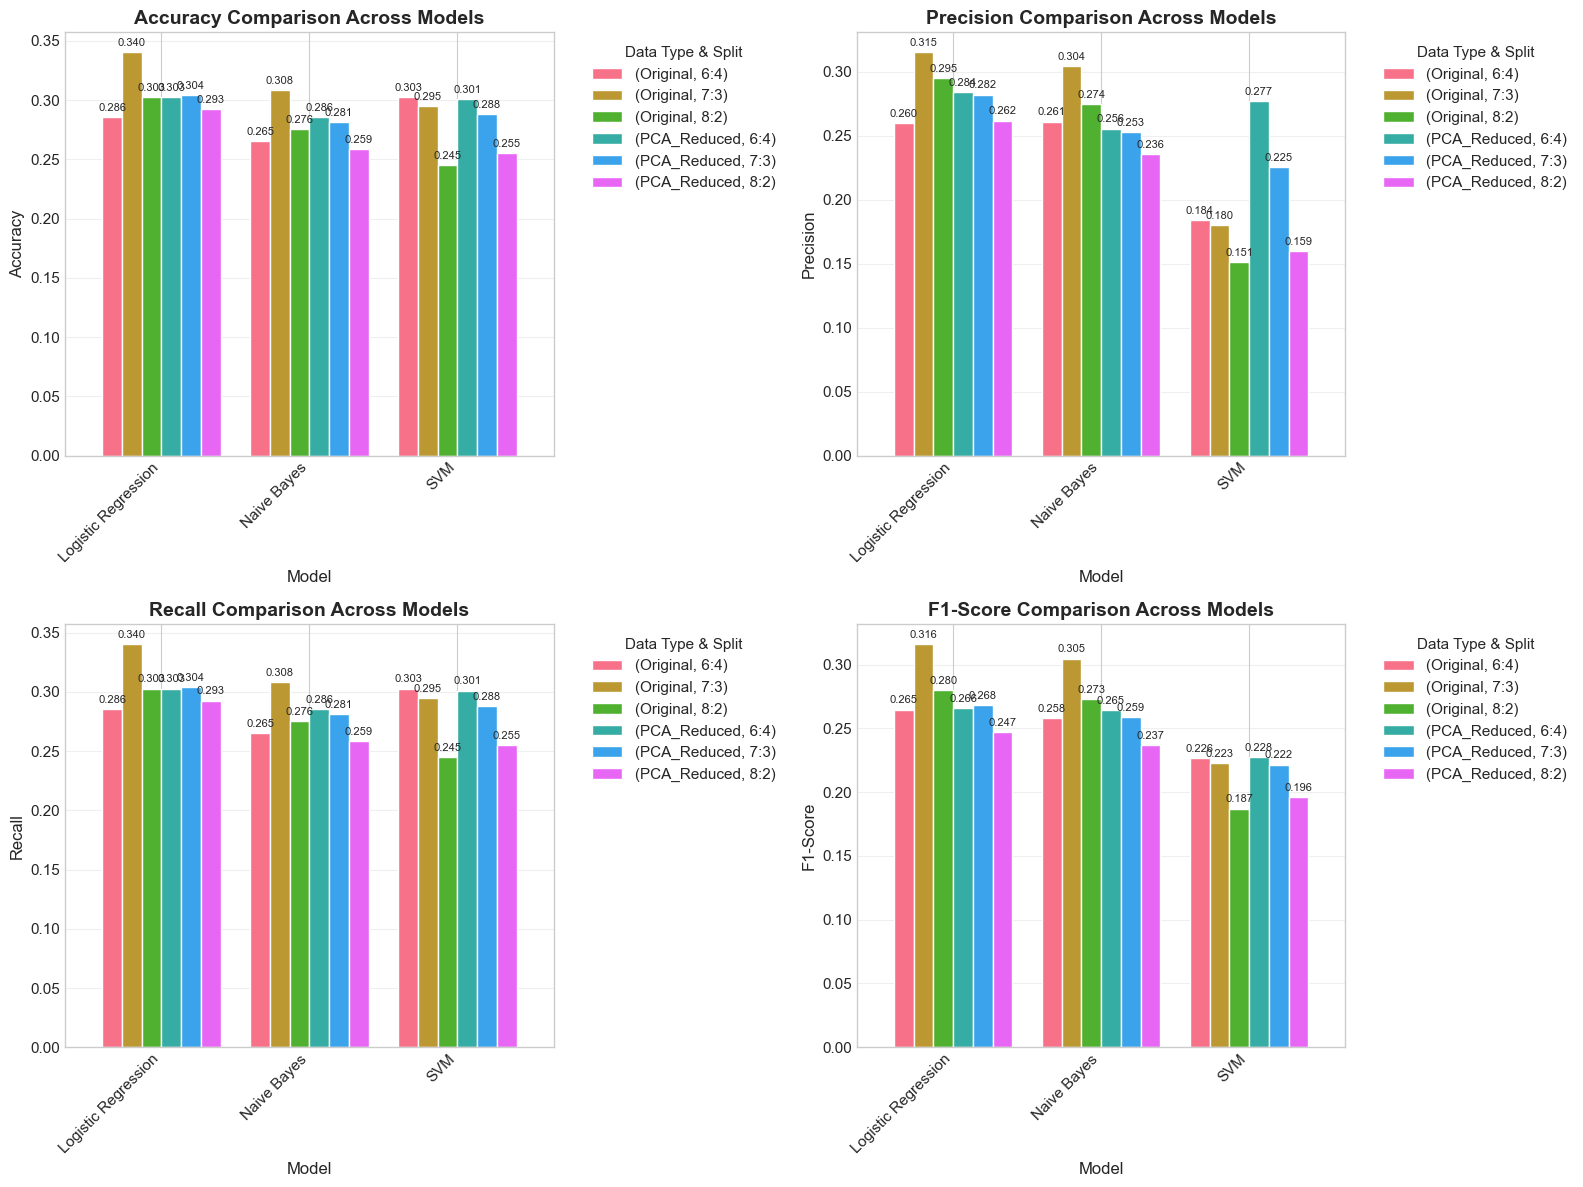

In [37]:
# Visualize kết quả
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[idx // 2, idx % 2]

    pivot_table = results_df.pivot_table(
        values=metric,
        index='model',
        columns=['data_type', 'split'],
        aggfunc='mean'
    )

    pivot_table.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title(f'{label} Comparison Across Models', fontsize=14, fontweight='bold')
    ax.set_ylabel(label, fontsize=12)
    ax.set_xlabel('Model', fontsize=12)
    ax.legend(title='Data Type & Split', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Thêm giá trị trên các cột
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8, padding=3)

plt.tight_layout()
plt.savefig('../results/classification_comparison_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. SO SÁNH DỮ LIỆU GỐC VS GIẢM CHIỀU


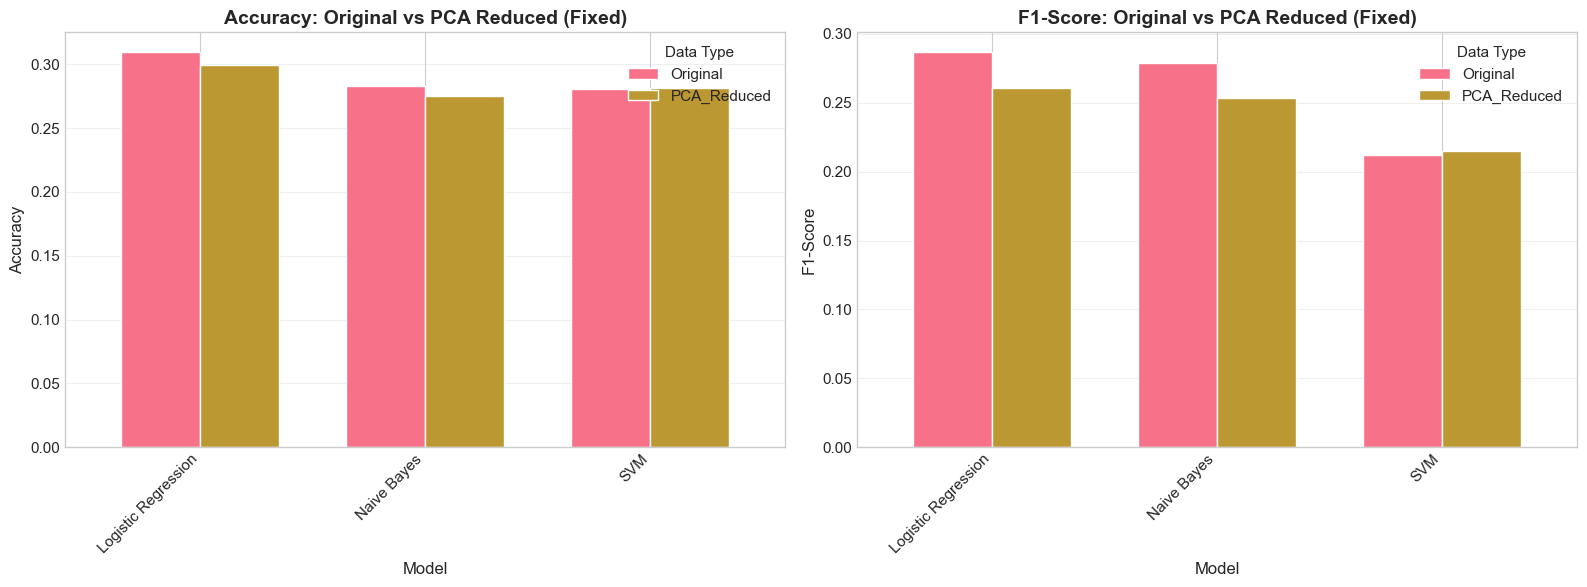

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# So sánh Accuracy
comparison_data = results_df.groupby(['model', 'data_type'])['accuracy'].mean().unstack()
comparison_data.plot(kind='bar', ax=axes[0], width=0.7)
axes[0].set_title('Accuracy: Original vs PCA Reduced (Fixed)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].legend(title='Data Type')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# So sánh F1-Score
comparison_data = results_df.groupby(['model', 'data_type'])['f1'].mean().unstack()
comparison_data.plot(kind='bar', ax=axes[1], width=0.7)
axes[1].set_title('F1-Score: Original vs PCA Reduced (Fixed)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].legend(title='Data Type')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../results/original_vs_pca_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. CONFUSION MATRIX CHO MÔ HÌNH TỐT NHẤT


MÔ HÌNH TỐT NHẤT
Model: Logistic Regression
Data Type: Original
Split: 7:3
Accuracy: 0.3401
Precision: 0.3149
Recall: 0.3401
F1-Score: 0.3159


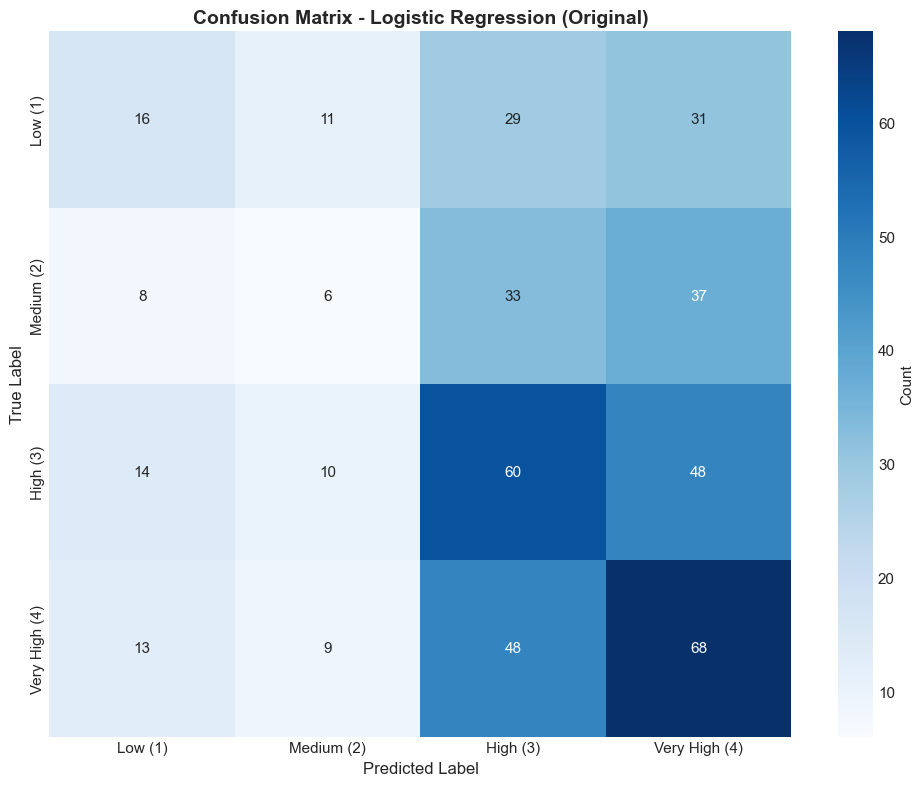


✓ Confusion matrix saved to '../results/confusion_matrix_best_fixed.png'

CLASSIFICATION REPORT
               precision    recall  f1-score   support

      Low (1)       0.31      0.18      0.23        87
   Medium (2)       0.17      0.07      0.10        84
     High (3)       0.35      0.45      0.40       132
Very High (4)       0.37      0.49      0.42       138

     accuracy                           0.34       441
    macro avg       0.30      0.30      0.29       441
 weighted avg       0.31      0.34      0.32       441



In [39]:
# Tìm mô hình tốt nhất dựa trên F1-score
best_idx = results_df['f1'].idxmax()
best_config = results_df.iloc[best_idx]

print("\n" + "=" * 80)
print("MÔ HÌNH TỐT NHẤT")
print("=" * 80)
print(f"Model: {best_config['model']}")
print(f"Data Type: {best_config['data_type']}")
print(f"Split: {best_config['split']}")
print(f"Accuracy: {best_config['accuracy']:.4f}")
print(f"Precision: {best_config['precision']:.4f}")
print(f"Recall: {best_config['recall']:.4f}")
print(f"F1-Score: {best_config['f1']:.4f}")
print("=" * 80)

# Train lại mô hình tốt nhất với split tốt nhất
best_split = best_config['split']
if best_split == '8:2':
    test_size = 0.2
elif best_split == '7:3':
    test_size = 0.3
else:
    test_size = 0.4

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42, stratify=y
)

# Nếu best model dùng PCA, apply PCA
if best_config['data_type'] == 'PCA_Reduced':
    pca = PCA(n_components=0.95, random_state=42)
    X_train = pca.fit_transform(X_train)
    X_test = pca.transform(X_test)
    print(f"\n✓ Applied PCA: {X_train.shape[1]} components")

# Khởi tạo và train mô hình tốt nhất
if best_config['model'] == 'Naive Bayes':
    best_model = GaussianNB()
elif best_config['model'] == 'Logistic Regression':
    best_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
elif best_config['model'] == 'SVM':
    best_model = SVC(kernel='rbf', random_state=42, probability=True)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low (1)', 'Medium (2)', 'High (3)', 'Very High (4)'],
            yticklabels=['Low (1)', 'Medium (2)', 'High (3)', 'Very High (4)'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_config["model"]} ({best_config["data_type"]})',
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('../results/confusion_matrix_best_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Confusion matrix saved to '../results/confusion_matrix_best_fixed.png'")

# Classification Report
print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(y_test, y_pred,
                            target_names=['Low (1)', 'Medium (2)', 'High (3)', 'Very High (4)']))

## 10. PHÂN TÍCH OVERFITTING

split               model   data_type  train_accuracy  test_accuracy      gap
  8:2         Naive Bayes    Original        0.354592       0.275510 0.079082
  8:2 Logistic Regression    Original        0.382653       0.302721 0.079932
  8:2                 SVM    Original        0.500850       0.244898 0.255952
  8:2         Naive Bayes PCA_Reduced        0.394558       0.258503 0.136054
  8:2 Logistic Regression PCA_Reduced        0.365646       0.292517 0.073129
  8:2                 SVM PCA_Reduced        0.579932       0.255102 0.324830
  7:3         Naive Bayes    Original        0.354713       0.308390 0.046323
  7:3 Logistic Regression    Original        0.388727       0.340136 0.048591
  7:3                 SVM    Original        0.484937       0.294785 0.190152
  7:3         Naive Bayes PCA_Reduced        0.382896       0.281179 0.101717
  7:3 Logistic Regression PCA_Reduced        0.371234       0.303855 0.067379
  7:3                 SVM PCA_Reduced        0.567541       0.28

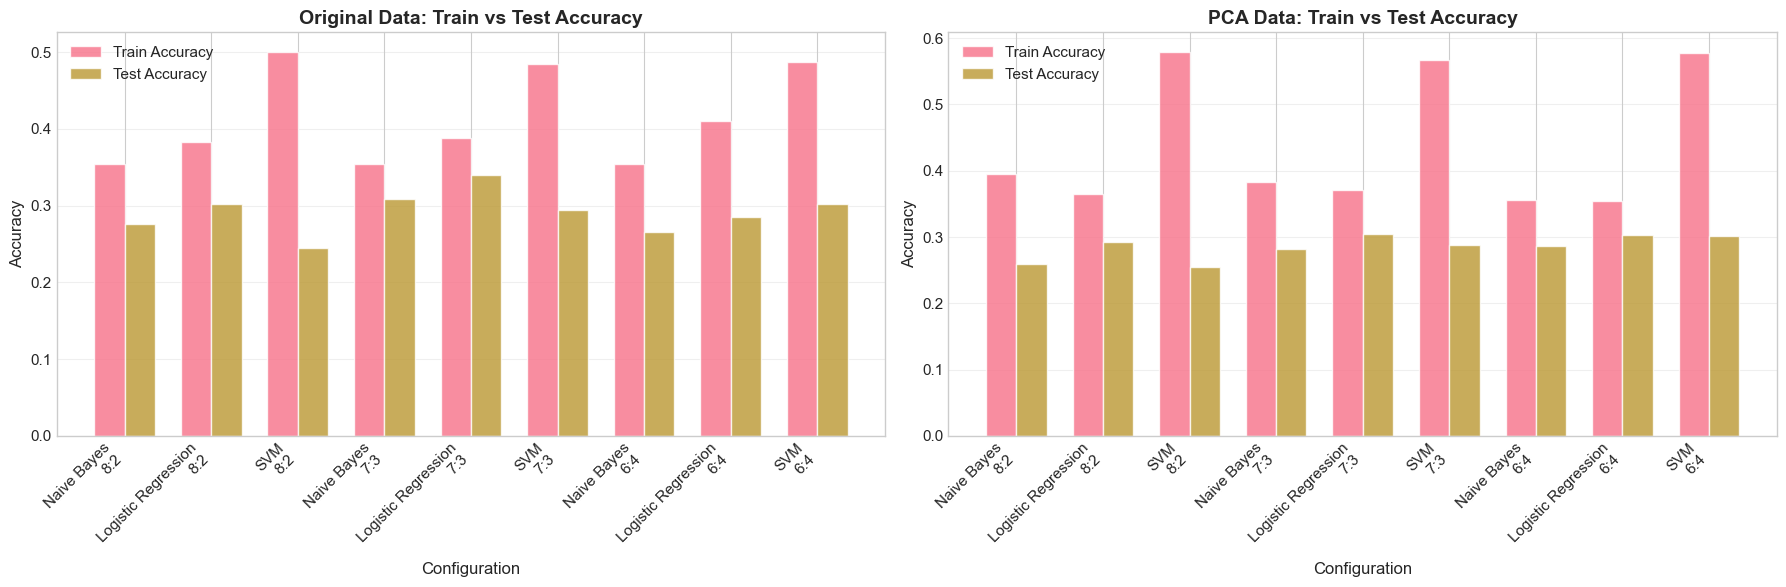


✓ Overfitting analysis saved to '../results/overfitting_analysis_fixed.png'


In [40]:
# Train lại với các split khác nhau và so sánh train vs test accuracy
splits_analysis = []

for train_size, test_size in train_test_splits:
    split_ratio = f"{int(train_size * 10)}:{int(test_size * 10)}"

    # Dữ liệu gốc
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    for model_name in selected_models:
        if model_name == 'Naive Bayes':
            model = GaussianNB()
        elif model_name == 'Logistic Regression':
            model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
        elif model_name == 'SVM':
            model = SVC(kernel='rbf', random_state=42)

        model.fit(X_train, y_train)

        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        gap = train_acc - test_acc

        splits_analysis.append({
            'split': split_ratio,
            'model': model_name,
            'data_type': 'Original',
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'gap': gap
        })

    # Dữ liệu PCA (FIXED)
    pca = PCA(n_components=0.95, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    for model_name in selected_models:
        if model_name == 'Naive Bayes':
            model = GaussianNB()
        elif model_name == 'Logistic Regression':
            model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
        elif model_name == 'SVM':
            model = SVC(kernel='rbf', random_state=42)

        model.fit(X_train_pca, y_train)

        train_acc = model.score(X_train_pca, y_train)
        test_acc = model.score(X_test_pca, y_test)
        gap = train_acc - test_acc

        splits_analysis.append({
            'split': split_ratio,
            'model': model_name,
            'data_type': 'PCA_Reduced',
            'train_accuracy': train_acc,
            'test_accuracy': test_acc,
            'gap': gap
        })

overfitting_df = pd.DataFrame(splits_analysis)
print(overfitting_df.to_string(index=False))

# Vẽ biểu đồ overfitting
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Original data
original_df = overfitting_df[overfitting_df['data_type'] == 'Original']
x = np.arange(len(original_df))
width = 0.35

axes[0].bar(x - width / 2, original_df['train_accuracy'], width, label='Train Accuracy', alpha=0.8)
axes[0].bar(x + width / 2, original_df['test_accuracy'], width, label='Test Accuracy', alpha=0.8)
axes[0].set_xlabel('Configuration', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Original Data: Train vs Test Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{row['model']}\n{row['split']}"
                         for _, row in original_df.iterrows()],
                        rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# PCA data
pca_df = overfitting_df[overfitting_df['data_type'] == 'PCA_Reduced']
x = np.arange(len(pca_df))

axes[1].bar(x - width / 2, pca_df['train_accuracy'], width, label='Train Accuracy', alpha=0.8)
axes[1].bar(x + width / 2, pca_df['test_accuracy'], width, label='Test Accuracy', alpha=0.8)
axes[1].set_xlabel('Configuration', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('PCA Data: Train vs Test Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{row['model']}\n{row['split']}"
                         for _, row in pca_df.iterrows()],
                        rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/overfitting_analysis_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Overfitting analysis saved to '../results/overfitting_analysis_fixed.png'")

## 11. SO SÁNH GAP THEO DATA TYPE


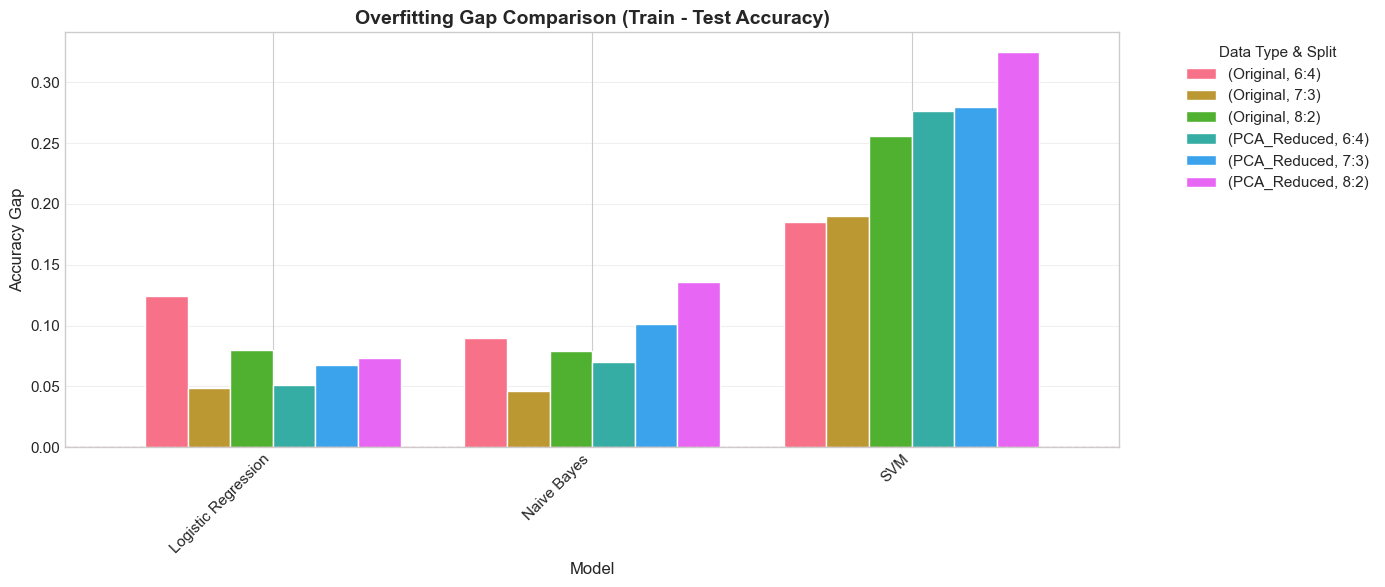

In [42]:
# Biểu đồ so sánh overfitting gap
fig, ax = plt.subplots(figsize=(14, 6))

gap_comparison = overfitting_df.pivot_table(
    values='gap',
    index='model',
    columns=['data_type', 'split'],
    aggfunc='mean'
)

gap_comparison.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Overfitting Gap Comparison (Train - Test Accuracy)', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy Gap', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.legend(title='Data Type & Split', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../results/overfitting_gap_comparison.png', dpi=300, bbox_inches='tight')
plt.show()